# DATA 612 - Project 1: Global Baseline Predictors and RMSE

**Name:** Noah Collin
**Course:** DATA 612

In this project I predict book ratings two different ways and compare them using RMSE:

1. **Raw average** - just predict the overall average rating for every reader and book.
2. **Baseline predictor** - the average plus a user bias and an item bias:

`prediction = average + user_bias + item_bias`

The idea is that some readers rate high or low in general, and some books are liked more
than others. Adding those two adjustments should give better predictions than the average
alone.

## Recommender system (business case)

This system **recommends data science books to readers**. Readers rate books from 1 to 5,
but most readers have only read a few of the books, so a lot of the ratings are missing.
To recommend a book, I need to estimate the rating a reader would give to a book they have
not read yet, and then suggest the books with the highest predicted ratings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. The data

I built a small toy dataset of 6 readers and 6 data science books, with some missing
ratings (each reader has not read every book). A small dataset like this is easy to check
by hand. `NaN` just means that reader did not rate that book.

In [ ]:
users = ["Hilary Mason", "DJ Patil", "Hadley Wickham",
         "Cathy O'Neil", "Nate Silver", "Andrew Gelman"]

items = ["The Signal and the Noise", "Weapons of Math Destruction", "The Undoing Project",
         "Naked Statistics", "Data Science for Business", "The Art of Statistics"]

# ratings from 1 to 5, NaN means not rated
ratings = [
    [5,    4,    np.nan, 4,    5,    3   ],
    [5,    5,    4,      5,    5,    np.nan],
    [3,    2,    1,      np.nan, 3,  1   ],
    [np.nan, 4,  3,      4,    5,    3   ],
    [4,    4,    np.nan, 4,    5,    3   ],
    [4,    np.nan, 2,    3,    4,    np.nan],
]

R = pd.DataFrame(ratings, index=users, columns=items)
R

,The Signal and the Noise,Weapons of Math Destruction,The Undoing Project,Naked Statistics,Data Science for Business,The Art of Statistics
Hilary Mason,5.0,4.0,NaN,4.0,5,3.0
DJ Patil,5.0,5.0,4.0,5.0,5,NaN
Hadley Wickham,3.0,2.0,1.0,NaN,3,1.0
Cathy O'Neil,NaN,4.0,3.0,4.0,5,3.0
Nate Silver,4.0,4.0,NaN,4.0,5,3.0
Andrew Gelman,4.0,NaN,2.0,3.0,4,NaN


In [3]:
print("Number of ratings we have:", int(R.notna().sum().sum()))
print("Number of ratings missing: ", int(R.isna().sum().sum()))

Number of ratings we have: 29
Number of ratings missing:  7


## 2. Split into training and test

First I reshape the matrix so there is one row per rating. Then I hold out 20% of the
ratings as a test set. I build everything (the average and the biases) using only the
training set, and then check how well it predicts the test set.

In [4]:
# one row per rating (stack drops the missing ones automatically)
long = R.stack().reset_index()
long.columns = ["user", "item", "rating"]
long["rating"] = long["rating"].astype(int)

# hold out 20% of the ratings for testing
test = long.sample(frac=0.2, random_state=2)
train = long.drop(test.index)

print("Training ratings:", len(train))
print("Test ratings:    ", len(test))
train.head()

Training ratings: 23
Test ratings:     6


,user,item,rating
2,Hilary Mason,Naked Statistics,4
3,Hilary Mason,Data Science for Business,5
4,Hilary Mason,The Art of Statistics,3
5,DJ Patil,The Signal and the Noise,5
6,DJ Patil,Weapons of Math Destruction,5


## 3. Raw average

The simplest prediction: use the average of all the training ratings as the guess for
every reader-book pair. I measure the error with RMSE (root mean squared error) - lower
is better.

In [5]:
raw_avg = train["rating"].mean()
print("Raw average rating:", round(raw_avg, 3))


def rmse(predicted, actual):
    predicted = np.array(predicted, dtype=float)
    actual = np.array(actual, dtype=float)
    return np.sqrt(np.mean((predicted - actual) ** 2))


# the raw-average prediction is the same number for every rating
rmse_raw_train = rmse([raw_avg] * len(train), train["rating"])
rmse_raw_test = rmse([raw_avg] * len(test), test["rating"])

print("Raw average RMSE on training:", round(rmse_raw_train, 3))
print("Raw average RMSE on test:    ", round(rmse_raw_test, 3))

Raw average rating: 3.696
Raw average RMSE on training: 1.081
Raw average RMSE on test:     1.375


## 4. User and item biases

A **user bias** is how much higher or lower a reader rates compared to the overall average.
An **item bias** is how much higher or lower a book is rated compared to the overall average.
A positive bias means above average, a negative bias means below average. I calculate both
from the training data.

In [6]:
user_bias = train.groupby("user")["rating"].mean() - raw_avg
item_bias = train.groupby("item")["rating"].mean() - raw_avg

print("User biases:")
print(user_bias.round(3))
print()
print("Item biases:")
print(item_bias.round(3))

User biases:
user
Andrew Gelman    -0.446
Cathy O'Neil      0.104
DJ Patil          1.054
Hadley Wickham   -1.446
Hilary Mason      0.304
Nate Silver       0.638
Name: rating, dtype: float64

Item biases:
item
Data Science for Business      0.704
Naked Statistics               0.304
The Art of Statistics         -0.696
The Signal and the Noise       0.304
The Undoing Project           -1.196
Weapons of Math Destruction    0.054
Name: rating, dtype: float64


## 5. Baseline predictor

Now I combine the three pieces:

`prediction = average + user_bias + item_bias`

I also keep every prediction between 1 and 5, because that is the rating range.

In [7]:
def predict(user, item):
    p = raw_avg + user_bias[user] + item_bias[item]
    return min(5, max(1, p))   # keep the prediction between 1 and 5


# baseline prediction for every reader-book combination
baseline = pd.DataFrame(index=users, columns=items, dtype=float)
for u in users:
    for i in items:
        baseline.loc[u, i] = predict(u, i)

baseline.round(2)

,The Signal and the Noise,Weapons of Math Destruction,The Undoing Project,Naked Statistics,Data Science for Business,The Art of Statistics
Hilary Mason,4.30,4.05,2.80,4.30,4.70,3.30
DJ Patil,5.00,4.80,3.55,5.00,5.00,4.05
Hadley Wickham,2.55,2.30,1.05,2.55,2.95,1.55
Cathy O'Neil,4.10,3.85,2.60,4.10,4.50,3.10
Nate Silver,4.64,4.39,3.14,4.64,5.00,3.64
Andrew Gelman,3.55,3.30,2.05,3.55,3.95,2.55


In [8]:
# quick check by hand for one reader and book
u, i = "Hadley Wickham", "The Undoing Project"
print("average:   ", round(raw_avg, 3))
print("user bias: ", round(user_bias[u], 3))
print("item bias: ", round(item_bias[i], 3))
print("prediction:", round(predict(u, i), 3))

average:    3.696
user bias:  -1.446
item bias:  -1.196
prediction: 1.054


In [9]:
train_pred = [predict(u, i) for u, i in zip(train["user"], train["item"])]
test_pred = [predict(u, i) for u, i in zip(test["user"], test["item"])]

rmse_base_train = rmse(train_pred, train["rating"])
rmse_base_test = rmse(test_pred, test["rating"])

print("Baseline RMSE on training:", round(rmse_base_train, 3))
print("Baseline RMSE on test:    ", round(rmse_base_test, 3))

Baseline RMSE on training: 0.318
Baseline RMSE on test:     0.518


## 6. Results

In [10]:
results = pd.DataFrame(
    {"Train RMSE": [rmse_raw_train, rmse_base_train],
     "Test RMSE":  [rmse_raw_test,  rmse_base_test]},
    index=["Raw average", "Baseline"],
)
results.round(3)

,Train RMSE,Test RMSE
Raw average,1.081,1.375
Baseline,0.318,0.518


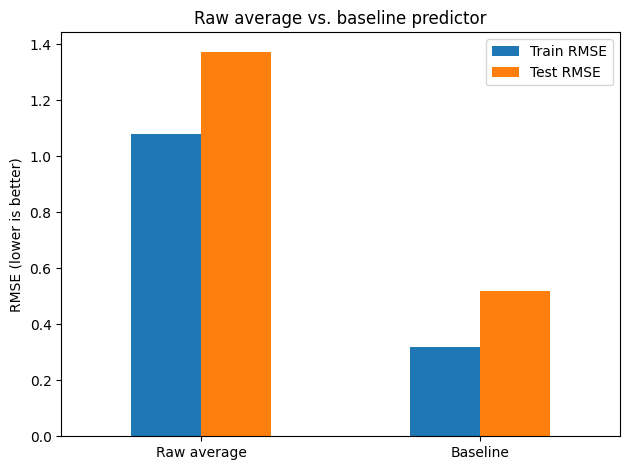

In [11]:
results.plot(kind="bar")
plt.ylabel("RMSE (lower is better)")
plt.title("Raw average vs. baseline predictor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Summary

The baseline predictor had a lower RMSE than the raw average on both the training set and
the test set. Adding the user and item biases helped because the data really does have
differences between readers (some rate high, some rate low) and between books (some are
liked more than others).

The raw average ignores who the reader is and which book it is, so it makes the same guess
every time. The baseline adjusts that guess up or down for each reader and book, which is
why it does better.

Because the dataset is small, the exact numbers would change a little with a different
random split, but the baseline beating the raw average is the result we expect.